# Decision-Making with Conformal and Venn Predictive Systems

Standard conformal prediction gives prediction sets or distributions — but how do we **act** on them?
This notebook demonstrates decision-making under predictive uncertainty using:

1. **Conformal Predictive Decision Making** (Vovk & Bendtsen 2018, Algorithm 1): for each decision $d$, train a separate CPS on utility-transformed labels $U(x_i, y_i, d)$ — the conformal mean of each utility-CPD gives the expected utility.
2. **Venn Predictive Decision Making Systems** (Venn-PDMS): select actions under multiprobability using decision criteria (maximin, Hurwicz α, minimax regret).

**Clinical scenario**: binary classification (malignant vs benign tumour) with three possible actions — *treat*, *dismiss*, or *defer to specialist*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from online_cp import (
    ConformalPredictiveDecisionMaker,
    VennAbersPredictor,
    UtilityFunction,
    venn_decision,
    alpha_utility,
    alpha_regret,
)

plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(42)

## 1. Data

The Wisconsin Breast Cancer dataset: 569 samples, 30 features, binary labels (0 = malignant, 1 = benign). We standardise features and shuffle.

In [2]:
cancer = load_breast_cancer()
X = StandardScaler().fit_transform(cancer.data)
y = cancer.target  # 0 = malignant, 1 = benign

# Shuffle
perm = rng.permutation(len(y))
X, y = X[perm], y[perm]

print(f"N = {len(y)}, features = {X.shape[1]}")
print(f"Class distribution: malignant={sum(y==0)}, benign={sum(y==1)}")

N = 569, features = 30
Class distribution: malignant=212, benign=357


## 2. Utility Function

Three decisions: **treat** (d=0), **dismiss** (d=1), **defer to specialist** (d=2).

| | Treat (d=0) | Dismiss (d=1) | Defer (d=2) |
|---|---|---|---|
| **Malignant (y=0)** | +10 (correct treatment) | −50 (missed cancer) | +5 (specialist catches it) |
| **Benign (y=1)** | −5 (unnecessary treatment) | +10 (correct, patient relieved) | −1 (unnecessary referral) |

This utility matrix reflects clinical asymmetry:
- Missing a malignant tumour is catastrophic (−50) — progression, delayed treatment, mortality risk
- Unnecessary treatment carries real morbidity (−5) but is far less severe
- Deferral is protective for malignant cases but wasteful for benign ones

In [3]:
# Utility matrix: U[y][d]
U_matrix = np.array([
    [+10.0, -50.0, +5.0],   # y=0 (malignant): treat=+10, dismiss=-50, defer=+5
    [ -5.0, +10.0, -1.0],   # y=1 (benign):    treat=-5,  dismiss=+10, defer=-1
])

def clinical_utility(x, y, d):
    return U_matrix[int(y), int(d)]

utility = UtilityFunction(clinical_utility, decisions=[0, 1, 2])

print("Utility matrix:")
print(f"  {'':12s} {'Treat':>8s} {'Dismiss':>8s} {'Defer':>8s}")
print(f"  {'Malignant':12s} {U_matrix[0,0]:>+8.0f} {U_matrix[0,1]:>+8.0f} {U_matrix[0,2]:>+8.0f}")
print(f"  {'Benign':12s} {U_matrix[1,0]:>+8.0f} {U_matrix[1,1]:>+8.0f} {U_matrix[1,2]:>+8.0f}")

Utility matrix:
                  Treat  Dismiss    Defer
  Malignant         +10      -50       +5
  Benign             -5      +10       -1


## 3. Conformal Predictive Decision Making (Vovk & Bendtsen 2018)

**Algorithm 1** from the paper: for each decision $d \in D$:
1. Transform training labels to utilities: $(x_i, y_i) \mapsto (x_i, U(x_i, y_i, d))$
2. Train a separate CPS $Q^*_d$ on these utility-transformed labels
3. Compute expected utility of $d$ as the conformal mean of $Q^*_d$

Return the decision with highest expected utility.

This gives a conformal guarantee **on the predicted utility itself** — unlike the naive approach of computing utility over a label-CPD.

In [4]:
# V&B Algorithm 1: online decision-making experiment
n_init = 50
cdm = ConformalPredictiveDecisionMaker(utility, a=1.0)
cdm.learn_initial_training_set(X[:n_init], y[:n_init])

decision_names = {0: "treat", 1: "dismiss", 2: "defer"}
cum_utility_vb = []
total_vb = 0.0
decisions_vb = []

for i in range(n_init, len(y)):
    x_i, y_i = X[i], y[i]
    tau = rng.uniform()
    d = cdm.predict(x_i, tau=tau)
    
    total_vb += clinical_utility(x_i, y_i, d)
    cum_utility_vb.append(total_vb)
    decisions_vb.append(d)
    
    cdm.learn_one(x_i, y_i)

n_test = len(y) - n_init
print(f"V&B Algorithm 1 — online over {n_test} steps:")
print(f"  Cumulative utility: {total_vb:.0f}  (avg {total_vb/n_test:.2f})")
for d_val in [0, 1, 2]:
    count = sum(1 for d in decisions_vb if d == d_val)
    print(f"  {decision_names[d_val]:>8s}: {count:4d} times ({100*count/n_test:.1f}%)")

V&B Algorithm 1 — online over 519 steps:
  Cumulative utility: 3590  (avg 6.92)
     treat:  186 times (35.8%)
   dismiss:  199 times (38.3%)
     defer:  134 times (25.8%)


## 4. Venn-Abers Decision Making

The Venn-Abers predictor produces probability intervals $[p_0, p_1]$ for $P(y=1|x)$.
Given the same utility function, we compute expected utilities under each Venn hypothesis and apply different criteria:

- **α-utility (α=0)**: maximin — assumes worst-case probability, conservative
- **α-utility (α=0.5)**: midpoint — averages best and worst case
- **α-utility (α=0.6)**: mildly optimistic blend of best-case and worst-case

With the 10:1 penalty for missing malignant tumours, the conservative α=0 criterion should favour "treat" or "defer" more often.

In [5]:
# Venn-Abers decision-making experiment
n_init_v = 50
vap = VennAbersPredictor(scorer="ridge", a=1.0)
vap.learn_initial_training_set(X[:n_init_v], y[:n_init_v])

criteria = [("utility", 0.0), ("utility", 0.5), ("utility", 0.6)]
labels = ["α-utility (α=0)", "α-utility (α=0.5)", "α-utility (α=0.6)"]
cum_utilities_venn = {l: [] for l in labels}
totals_venn = {l: 0.0 for l in labels}
decisions_venn = {l: [] for l in labels}
saved_predictions = []

for i in range(n_init_v, len(y)):
    x_i, y_i = X[i], y[i]
    venn_pred = vap.predict(x_i)
    saved_predictions.append((x_i, y_i, venn_pred))
    
    for (crit, a), label in zip(criteria, labels):
        d = venn_decision(venn_pred, utility, x_i, criterion=crit, alpha=a)
        u = clinical_utility(x_i, y_i, d)
        totals_venn[label] += u
        cum_utilities_venn[label].append(totals_venn[label])
        decisions_venn[label].append(d)
    
    vap.learn_one(x_i, y_i)

n_test_v = len(y) - n_init_v
print(f"Venn-Abers — online over {n_test_v} steps:")
print(f"{'Criterion':>20s} {'Total':>8s} {'Avg':>6s}  {'Treat':>6s} {'Dismiss':>8s} {'Defer':>6s}")
for label in labels:
    counts = [sum(1 for d in decisions_venn[label] if d == v) for v in [0, 1, 2]]
    print(f"{label:>20s} {totals_venn[label]:>+8.0f} {totals_venn[label]/n_test_v:>+6.2f}  "
          f"{counts[0]:>6d} {counts[1]:>8d} {counts[2]:>6d}")

Venn-Abers — online over 519 steps:
           Criterion    Total    Avg   Treat  Dismiss  Defer
     α-utility (α=0)    +3990  +7.69     173      265     81
   α-utility (α=0.5)    +4175  +8.04     197      281     41
   α-utility (α=0.6)    +4156  +8.01     208      286     25


## 5. Comparison

Plot cumulative utility for all approaches on the same axes.

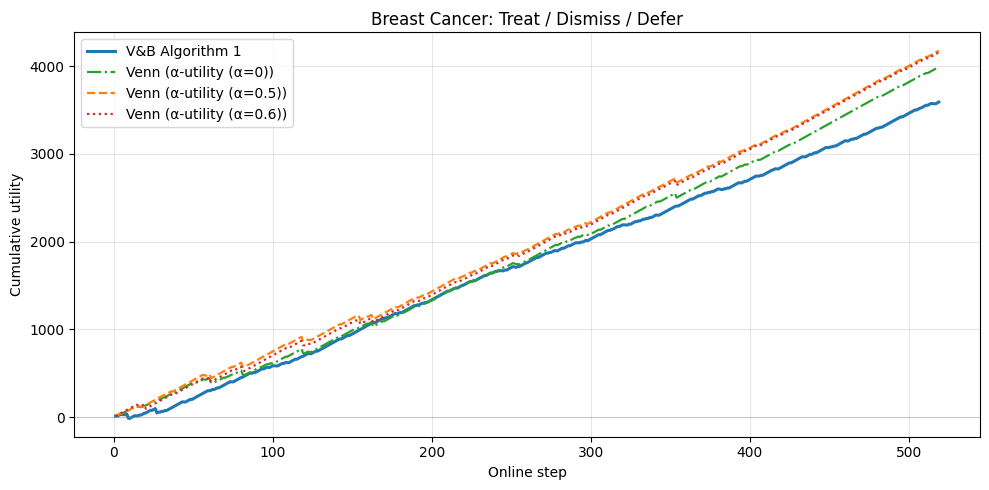

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
steps = np.arange(1, n_test + 1)

# V&B
ax.plot(steps, cum_utility_vb, label="V&B Algorithm 1", linewidth=2.2, color="C0")

# Venn criteria
styles = {"α-utility (α=0)": ("-.", "C2"), "α-utility (α=0.5)": ("--", "C1"), "α-utility (α=0.6)": (":", "C3")}
for label in labels:
    ls, col = styles[label]
    ax.plot(steps, cum_utilities_venn[label], label=f"Venn ({label})",
            linewidth=1.6, linestyle=ls, color=col)

ax.axhline(0, color="gray", linewidth=0.5, alpha=0.5)
ax.set_xlabel("Online step")
ax.set_ylabel("Cumulative utility")
ax.set_title("Breast Cancer: Treat / Dismiss / Defer")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Sensitivity to α (Hurwicz parameter)

The Hurwicz criterion interpolates between optimism (α=1) and pessimism (α=0 = maximin). We sweep α and replay the saved Venn predictions — no re-training.

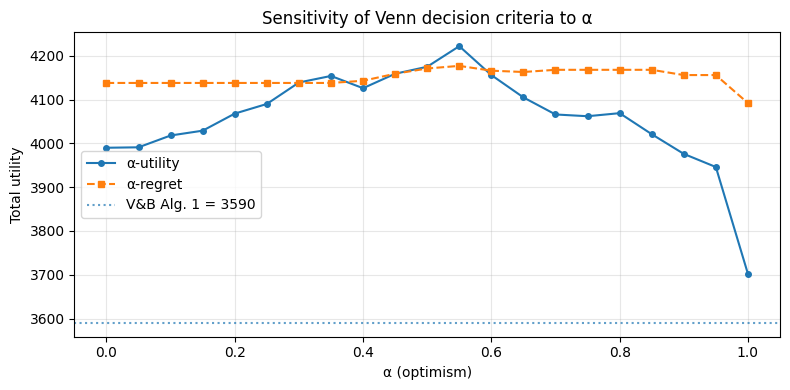

Optimal α: α-utility=0.55, α-regret=0.55


In [7]:
# α-sweep using saved predictions
alphas = np.linspace(0, 1, 21)
total_utility_sweep = []
total_regret_sweep = []

for alpha in alphas:
    tu, tr = 0.0, 0.0
    for (x_i, y_i, venn_pred) in saved_predictions:
        d_u = venn_decision(venn_pred, utility, x_i, criterion="utility", alpha=alpha)
        d_r = venn_decision(venn_pred, utility, x_i, criterion="regret", alpha=alpha)
        tu += clinical_utility(x_i, y_i, d_u)
        tr += clinical_utility(x_i, y_i, d_r)
    total_utility_sweep.append(tu)
    total_regret_sweep.append(tr)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(alphas, total_utility_sweep, "o-", label="α-utility", markersize=4)
ax.plot(alphas, total_regret_sweep, "s--", label="α-regret", markersize=4)
ax.axhline(total_vb, color="C0", linestyle=":", alpha=0.7, label=f"V&B Alg. 1 = {total_vb:.0f}")
ax.set_xlabel("α (optimism)")
ax.set_ylabel("Total utility")
ax.set_title("Sensitivity of Venn decision criteria to α")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal α: α-utility={alphas[np.argmax(total_utility_sweep)]:.2f}, "
      f"α-regret={alphas[np.argmax(total_regret_sweep)]:.2f}")

## Summary

| Method | Key idea |
|--------|----------|
| **V&B Algorithm 1** | One CPS per decision, trained on utility-transformed labels. Conformal guarantee on predicted utility. |
| **Venn (α-utility, α=0)** | Maximin: worst-case probability → conservative, avoids catastrophic misses. |
| **Venn (α-utility, α=0.5)** | Midpoint: average of best/worst case. |
| **Venn (α-utility, α=0.6)** | Mildly optimistic blend of best-case and worst-case. |

**API used**: `ConformalPredictiveDecisionMaker`, `UtilityFunction`, `VennAbersPredictor`, `venn_decision`, `alpha_utility`, `alpha_regret`